In [1]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import norm

# import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split

In [3]:
# !pip install git+https://github.com/bartz-org/bartz.git
!uv pip install bartz

if torch.cuda.is_available():
    !pip install bartz[cuda13]

from bartz import Bart
from bartz.BART import gbart, mc_gbart

!pip show bartz

Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 547ms
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------     0 B/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.83 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.83 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.83 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.83 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.83 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 20.04 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 20.04 KiB/20.04 KiB
⠙ Preparing packages... 

# 1. LOAD DATA

In [4]:
TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e9/train.csv"
TEST_PATH  = "/kaggle/input/competitions/playground-series-s6e9/test.csv"
SUB_PATH   = "/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv"
ORIG_PATH  = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
orig  = pd.read_csv(ORIG_PATH)

submission = pd.read_csv(SUB_PATH)

# 2.  FEATURE ENGINEERING

In [5]:
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET] = orig[TARGET].map({'Yes': 1, 'No': 0})

train['is_train'] = 1
test['is_train'] = 0
test[TARGET] = np.nan
combined = pd.concat([train, test], ignore_index=True)
combined.drop(columns=['Number_of_Cars_Owned'], inplace=True, errors='ignore')

cat_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in combined.columns if c not in cat_cols + ['id', 'is_train', TARGET]]

# Extract digits from the 10^-4 place up to the 10^3 place
digit_features = []
for c in num_cols:
    for k in range(-4, 4):
        col_name = f"{c}_digit{k}"
        combined[col_name] = (combined[c].fillna(0) // (10**k) % 10).astype('int8')
        digit_features.append(col_name)

# Add the new digit features so they get processed by your frequency/target encoders
num_cols.extend(digit_features)

# Map Original Dataset Target Means
orig_global_mean = orig[TARGET].mean()
for col in cat_cols + num_cols:
    if col in orig.columns:
        real_world_stats = orig.groupby(col, observed=False)[TARGET].mean()
        combined[f"{col}_org_mean"] = combined[col].map(real_world_stats).fillna(orig_global_mean).astype(float)

# Convert Numerics to String Categories
num_to_cat_cols = []
for col in num_cols:
    cat_name = f"{col}_cat"
    combined[cat_name] = combined[col].fillna('NaN').astype(str)
    num_to_cat_cols.append(cat_name)

# Global Frequency Encoding
all_cats = cat_cols + num_to_cat_cols
for col in all_cats:
    freq_mapping = combined[col].value_counts(normalize=True).to_dict()
    combined[f"{col}_fe"] = combined[col].map(freq_mapping).astype(float).fillna(0.0)

# The Mode Collapse Spike
# combined['is_30k_spike'] = (combined['Annual_Income_USD'] == 30000.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Millionaire Cliff (100% buy rate region)
# combined['is_millionaire_cliff'] = (combined['Annual_Income_USD'] >= 170537.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Dead Zone (0% buy rate region)
# combined['is_dead_zone'] = ((combined['Annual_Income_USD'] >= 38000.0) & (combined['Annual_Income_USD'] <= 42000.0)).astype('int8')  # Pruned! the XGBoost model do need it
# Environmental Concern Extremes
combined['is_env_hater'] = (combined['Environmental_Concern_Level'] == 1).astype('int8')

# Markus's "Smooth Keys" (Binned Numerics)
combined['income_exact_int'] = np.floor(combined['Annual_Income_USD']).astype(str)
combined['income100_floor']  = np.floor(combined['Annual_Income_USD'] / 100.0).astype(str)
combined['income1000_floor'] = np.floor(combined['Annual_Income_USD'] / 1000.0).astype(str)
combined['commute_integer']  = np.floor(combined['Daily_Commute_km']).astype(str)
# Adding these 4 new string columns to all_cats so they get Frequency and Target Encoded
all_cats.extend(['income_exact_int', 'income100_floor', 'income1000_floor', 'commute_integer'])

train = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test = combined[combined['is_train'] == 0].drop(columns=['is_train', TARGET])

#  FEATURE DROPPING
# Identify numeric columns to evaluate for correlatio (ignore strings/objects because .corr() will fail on them)
eval_cols = [c for c in train.columns if c not in ['id', TARGET] and pd.api.types.is_numeric_dtype(train[c])]

# Find perfectly correlated features (1.0 correlation)
corr_matrix = train[eval_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] == 1.0)]

# Find constant features (only 1 unique value) in train or test
to_drop_const = [c for c in train.columns if train[c].nunique() == 1] + \
                [c for c in test.columns if test[c].nunique() == 1]

# Combine all bad features into a set to drop
DROP = set(to_drop_corr).union(set(to_drop_const))
DROP = [c for c in DROP if c not in ['id', TARGET]] 

if len(DROP) > 0:
    print(f"   -> Dropping {len(DROP)} redundant/constant features: {DROP}")
    train.drop(columns=DROP, inplace=True, errors='ignore')
    test.drop(columns=DROP, inplace=True, errors='ignore')

FEATURES = [c for c in test.columns if c != 'id']
TARGET_ENCODE_COLS = [c for c in all_cats if c not in DROP] 

print(f"✅ Total Features: {len(FEATURES)}")
print(f"✅ Columns to Target Encode: {len(TARGET_ENCODE_COLS)}")

   -> Dropping 85 redundant/constant features: ['Charging_Stations_Near_Work_digit-3_cat_fe', 'Charging_Stations_Near_Home_digit3_cat', 'Age_digit-1_cat_fe', 'Charging_Stations_Near_Home_digit2_cat_fe', 'Annual_Income_USD_digit-2', 'Charging_Stations_Near_Home_digit2', 'Charging_Stations_Near_Home_digit-3_cat_fe', 'Age_digit-2', 'Annual_Income_USD_digit-3', 'Environmental_Concern_Level_digit-2_cat', 'Annual_Income_USD_digit-2_cat_fe', 'Age_digit3_cat', 'Charging_Stations_Near_Work_digit-3', 'Environmental_Concern_Level_digit-1_cat_fe', 'Age_digit-1_cat', 'Environmental_Concern_Level_digit0', 'Charging_Stations_Near_Work_digit-1_cat_fe', 'Annual_Income_USD_digit-4', 'Annual_Income_USD_digit-3_cat', 'Age_digit3', 'Environmental_Concern_Level_digit-1_cat', 'Annual_Income_USD_digit-2_cat', 'Environmental_Concern_Level_digit1_cat_fe', 'Charging_Stations_Near_Home_digit-1', 'Charging_Stations_Near_Work_digit2_cat_fe', 'Environmental_Concern_Level_digit3_cat_fe', 'Environmental_Concern_Level_

In [6]:
# ==========================================
# MANUAL FEATURE PRUNING (Calculated via Gain Thresholding)
# ==========================================
print("✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...")

features_to_drop = [
    'Age', 'Daily_Commute_km_digit-3_cat_TE_100', 'Charging_Stations_Near_Home_digit0',
    'Daily_Commute_km_digit1_cat_TE_100', 'Annual_Income_USD_digit1', 'Charging_Stations_Near_Work_digit1_cat_TE_auto',
    'Daily_Commute_km_digit1_cat_TE_auto', 'Daily_Commute_km_digit0_cat_TE_10', 'Gender_org_mean',
    'Daily_Commute_km_digit-4_cat_TE_100', 'Daily_Commute_km_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_auto',
    'Daily_Commute_km_cat_fe', 'Annual_Income_USD_digit1_cat_fe', 'Charging_Stations_Near_Work_digit0_cat_TE_100',
    'Annual_Income_USD_digit2_cat_TE_100', 'Annual_Income_USD_digit0', 'Charging_Stations_Near_Home_digit-3_cat_TE_auto',
    'Gender_TE_100', 'Current_Car_Type_TE_10', 'Age_digit1_cat_fe', 'Charging_Stations_Near_Work_digit1_cat_TE_100',
    'Annual_Income_USD_digit0_cat_TE_10', 'Daily_Commute_km_digit-3_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_10',
    'Gender_TE_auto', 'Daily_Commute_km_digit0_cat_TE_100', 'Charging_Stations_Near_Home_digit-4_cat_TE_auto',
    'Daily_Commute_km_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_auto', 'Daily_Commute_km_digit-1',
    'Charging_Stations_Near_Work_digit0', 'Annual_Income_USD_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_10',
    'Charging_Stations_Near_Work_digit-3_cat_TE_auto', 'Charging_Stations_Near_Work_org_mean', 'Age_digit0_cat_TE_auto',
    'Age_digit0_cat_fe', 'Annual_Income_USD_digit0_cat_fe', 'Charging_Stations_Near_Home_digit-4_cat_TE_100',
    'Daily_Commute_km_digit-3_cat_TE_auto', 'Age_digit0', 'Annual_Income_USD_digit2_cat_TE_auto',
    'Annual_Income_USD_digit0_cat_TE_100', 'Daily_Commute_km_org_mean', 'Age_digit0_cat_TE_10',
    'Current_Car_Type_TE_auto', 'Current_Car_Type_TE_100', 'Age_digit1_cat_TE_auto', 'Charging_Stations_Near_Home_digit-4',
    'Annual_Income_USD_digit2_cat_TE_10', 'Daily_Commute_km_digit-1_cat_TE_100', 'Age_cat_fe',
    'Daily_Commute_km_digit0_cat_fe', 'Daily_Commute_km_digit-1_cat_fe', 'Daily_Commute_km_digit-1_cat_TE_auto',
    'Daily_Commute_km_digit-2_cat_TE_10', 'Age_digit1', 'Age_digit1_cat_TE_100', 'Gender_TE_10', 'Age_digit1_cat_TE_10',
    'Age_digit0_cat_TE_100', 'Daily_Commute_km_digit-3', 'Charging_Stations_Near_Home_digit-3_cat_TE_100', 'Gender_fe',
    'Charging_Stations_Near_Home_digit-3_cat_TE_10', 'Daily_Commute_km_digit-4_cat_fe', 'Daily_Commute_km_digit-4',
    'Daily_Commute_km_digit-3_cat_fe', 'Charging_Stations_Near_Work_digit-3_cat_TE_10', 'Daily_Commute_km_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_auto', 'Charging_Stations_Near_Home_digit-1_cat_TE_auto',
    'Charging_Stations_Near_Work_digit1_cat_fe', 'Charging_Stations_Near_Work_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_100', 'Charging_Stations_Near_Work_digit-3_cat_TE_100', 'is_dead_zone',
    'is_millionaire_cliff', 'is_30k_spike', 'Charging_Stations_Near_Home_digit-1_cat_TE_100',
    'Charging_Stations_Near_Home_digit-1_cat_TE_10', 'Charging_Stations_Near_Home_digit-2_cat_TE_10',
    'Charging_Stations_Near_Work_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit-2_cat_TE_auto',
    'Charging_Stations_Near_Work_digit-1_cat_TE_auto', 'Charging_Stations_Near_Work_digit-1_cat_TE_100',
    'Charging_Stations_Near_Work_digit-2_cat_TE_10'
]

✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...


# 3. 10 FOLD CV WITH SKLEARN TARGET ENCODING

In [7]:
## -- Tell JAX to use all and only 95% of the GPU memory
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = '.95'

print("📥 Memory limited to 95% usage")

📥 Memory limited to 95% usage


In [8]:
USE_FULL_TRAIN = True
MODEL_NAME = 'BARTZ'

x_sample, x_sample2 = train_test_split(train, train_size=20_000, stratify=train[TARGET], random_state=42)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,Age,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,...,Charging_Stations_Near_Home_digit0_cat_fe,Charging_Stations_Near_Home_digit1_cat_fe,Charging_Stations_Near_Work_digit-4_cat_fe,Charging_Stations_Near_Work_digit0_cat_fe,Charging_Stations_Near_Work_digit1_cat_fe,is_env_hater,income_exact_int,income100_floor,income1000_floor,commute_integer
0,0,66,92887.0,23.4,3,7,1.0,Male,Suburban,Sedan,...,0.119869,0.839831,0.961491,0.095176,0.742066,1,92887.0,928.0,92.0,23.0
1,1,38,30000.0,5.0,2,2,4.0,Male,Rural,SUV,...,0.183997,0.839831,0.961491,0.100067,0.742066,0,30000.0,300.0,30.0,5.0
2,2,26,94389.0,36.8,8,15,5.0,Female,Urban,Sedan,...,0.031121,0.839831,0.961491,0.094157,0.257934,0,94389.0,943.0,94.0,36.0
3,3,66,73580.0,23.7,6,9,3.0,Male,Suburban,Hatchback,...,0.083082,0.839831,0.961491,0.099631,0.742066,0,73580.0,735.0,73.0,23.0
4,4,54,57898.0,50.8,2,3,3.0,Male,Suburban,Hatchback,...,0.183997,0.839831,0.961491,0.145295,0.742066,0,57898.0,578.0,57.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,5,6,5.0,Male,Urban,Sedan,...,0.079342,0.839831,0.961491,0.103372,0.742066,0,71090.0,710.0,71.0,27.0
668661,668661,32,129990.0,5.0,5,4,1.0,Female,Suburban,SUV,...,0.079342,0.839831,0.961491,0.094156,0.742066,1,129990.0,1299.0,129.0,5.0
668662,668662,64,121791.0,24.2,5,6,1.0,Female,Suburban,Hatchback,...,0.079342,0.839831,0.961491,0.103372,0.742066,1,121791.0,1217.0,121.0,24.0
668663,668663,51,115923.0,43.7,0,0,1.0,Female,Rural,SUV,...,0.134657,0.839831,0.038509,0.061778,0.742066,1,115923.0,1159.0,115.0,43.0


In [9]:
%%time

FOLDS = 10
print(f"\n🚀 Training {MODEL_NAME} with {FOLDS} Folds...")

X = train_data[FEATURES]
y = train_data[TARGET]
X_test = test[FEATURES] #.iloc[:len(test) // 10]

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []

# feature_importances = pd.DataFrame()

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
    X_test_fold = X_test.copy()

    # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
    te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
    te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
    te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)

    X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])

    for i, col in enumerate(TARGET_ENCODE_COLS):
        # Auto smoothing TE
        X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
        X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
        X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')
        
        # Strict (10.0) smoothing TE
        X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
        X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
        X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')

        # Massive (100.0) smoothing TE (Markus's method)
        X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
        X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
        X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')
        
        # Drop the original string column
        X_train.drop(columns=[col], inplace=True)
        X_valid.drop(columns=[col], inplace=True)
        X_test_fold.drop(columns=[col], inplace=True)
        
    # APPLY DYNAMIC PRUNING
    if len(features_to_drop) > 0:
        # Check X_train.columns because it contains both base features and the new _TE_ features
        safe_to_drop = [c for c in features_to_drop if c in X_train.columns]
        
        if len(safe_to_drop) > 0:
            if fold == 1:
                print(f"   -> Successfully pruned {len(safe_to_drop)} features.")
                
            X_train.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_valid.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_test_fold.drop(columns=safe_to_drop, inplace=True, errors='ignore')

    # --- TUNED HISTGRADIENT MODEL ---
    engine = "pbart"
    params = {
        "type":  engine,
        # 'ntree':  100, # d=50
        # 'ndpost': 2000, # d=1000
        # 'nskip':  150, # d=100
        # 'k': 4.0, # d=2.0
        # 'numcut': 255, # d=100
        # 'usequants': True,
        'sparse': True,
        'augment':True,
        'mc_cores': 20, # d=2
        'keepevery': 5, # d=10
        "seed": 42,
    }
    clf = mc_gbart(
        X_train.to_numpy(),
        y_train.astype(bool).to_numpy() if engine == "pbart" else y_train.astype('float32').to_numpy(),
        x_test=X_valid.to_numpy(),
        **params,
    )
    # print(f"prob_test_mean: {len(clf.prob_test_mean)}")
    # print(clf.prob_test_mean)

    oof_preds[valid_idx] = norm.cdf(clf.predict(X_valid.to_numpy()).mean(axis=0).flatten())
    test_preds += norm.cdf(clf.predict(X_test_fold.to_numpy()).mean(axis=0).flatten()) / FOLDS

    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    fold_scores.append(fold_auc)
    print(f" -> Post {fold} AUC: {roc_auc_score(y_valid, clf.prob_test_mean):.6f}")
    # print(f" -> CDF_ {fold} AUC: {roc_auc_score(y_valid, norm.cdf(oof_preds[valid_idx])):.6f}")
    print(f" -> Fold {fold} AUC: {fold_auc:.6f}\n")

    del clf, X_train, X_valid, y_train, y_valid, X_test_fold
    torch.cuda.empty_cache()

oof_auc = roc_auc_score(y, oof_preds)
avg_auc = np.mean(fold_scores)
std_auc = np.std(fold_scores)

print("\n" + "="*45)
print(f"🏆 {MODEL_NAME} OOF AUC: {oof_auc:.6f}")
print(f"🏆 {MODEL_NAME} AVG AUC: {avg_auc:.6f} ± {std_auc:.6f}")
print("="*45)


🚀 Training BARTZ with 10 Folds...
   -> Successfully pruned 85 features.


ERROR:2026-09-20 20:55:33,077:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda13/__init__.py", line 334, in initialize
    c_api = xb.register_plugin(
            ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 621, in register_plugin
    c_api = xla_client.load_pjrt_plugin_dynamically(plugin_name, library_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jaxlib/xla_client.py", line 113, in load_pjrt_plugin_dynamically
    return _xla.load_pjrt_plugin(plugin_name, library_path, c_api=None)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  0%|          | 0/350 [00:00<?, ?it/s]

 -> Post 1 AUC: 0.945026
 -> Fold 1 AUC: 0.945059



  0%|          | 0/350 [00:00<?, ?it/s]

...

 -> Post 8 AUC: 0.946730
 -> Fold 8 AUC: 0.946762



  0%|          | 0/350 [00:00<?, ?it/s]

 -> Post 9 AUC: 0.946870
 -> Fold 9 AUC: 0.946900



  0%|          | 0/350 [00:00<?, ?it/s]

 -> Post 10 AUC: 0.945030
 -> Fold 10 AUC: 0.945049


🏆 BARTZ OOF AUC: 0.945968
🏆 BARTZ AVG AUC: 0.945971 ± 0.000785
CPU times: user 21min 55s, sys: 2min 21s, total: 24min 17s
Wall time: 24min 18s


In [10]:
# mc_cores=20 + keepevery=5 + sparse=True + augment=True
# =============================================
# 🏆 BARTZ OOF AUC: 0.942395
# 🏆 BARTZ AVG AUC: 0.942499 ± 0.001486
# =============================================
# CPU times: user 10min 26s, sys: 9.97 s, total: 10min 36s
# Wall time: 6min 52s

In [11]:
print(min(oof_preds), max(oof_preds))
print(min(test_preds), max(test_preds))
# print(min(norm.cdf(oof_preds)), max(norm.cdf(oof_preds)), min(norm.cdf(test_preds)), max(norm.cdf(test_preds)))

1.0425425217014758e-08 0.9999987076572685
1.9682960817961697e-08 0.9999956780147854


# 4. SAVE SUBMISSION AND OOF PREDICTIONS

In [12]:
print("\n" + "="*45)
print(f"🏆 {MODEL_NAME} OOF AUC: {oof_auc:.6f}")
print(f"🏆 {MODEL_NAME} AVG AUC: {avg_auc:.6f} ± {std_auc:.6f}")
print("="*45)

MODEL_NAME = f"{MODEL_NAME}_Triple_TE"

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc:.6f}.npy", test_preds)
print(f"\n💾 Saved 'test_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc:.6f}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc:.6f}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc:.6f}.csv'\n")

submission


🏆 BARTZ OOF AUC: 0.945968
🏆 BARTZ AVG AUC: 0.945971 ± 0.000785

💾 Saved 'test_BARTZ_Triple_TE_0.945968.npy'
💾 Saved 'oof_BARTZ_Triple_TE_0.945968.npy'
💾 Saved 'submission_BARTZ_Triple_TE_0.945968.csv'



,id,Will_Buy_EV
0,668665,0.032293
1,668666,0.019638
2,668667,0.002378
3,668668,0.001123
4,668669,0.032405
...,...,...
286566,955231,0.000147
286567,955232,0.307024
286568,955233,0.000094
286569,955234,0.000290


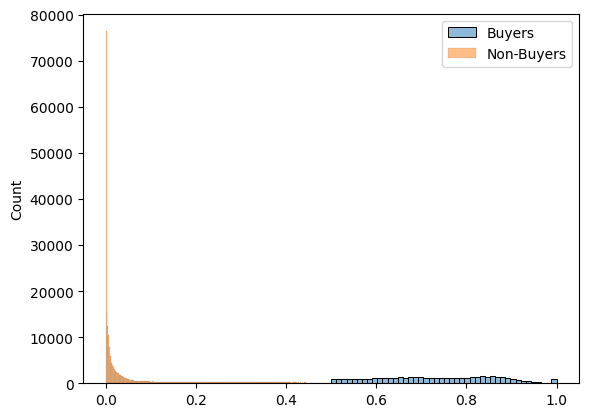

In [13]:
buyers = test_preds[test_preds >= 0.5]
non_buyers = test_preds[test_preds < 0.5]

ax = sns.histplot(buyers, label="Buyers", alpha=0.5)
sns.histplot(non_buyers, label="Non-Buyers", alpha=0.5, ax=ax)
plt.legend()
plt.show()

In [14]:
# !rm -r /kaggle/working/